# Creating memories

- It is just checking if these is some memory that must be remembered as a part of long term memory and it adds it into the memory
- This file does not teach how to use the memory just teaches on how to add memory
- Workflow
    - START -> Remember -> END
- The remember node just checks if the given message has some memory or not, if yes then it will store it 
- To extract the memory from the message an LLM is required

In [1]:

from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.runnables import RunnableConfig
import uuid

/Users/ritumalage/Documents/my_github/Notes/.venv_langgraph/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Creating a new store

In [2]:
store = InMemoryStore()

In [3]:
model = ChatGroq(model = "qwen/qwen3-32b") 

# Pydantic Model defination
- We want a controlled output from our LLM
- 2 information is required 
    1. Whether there is memory that exists in the given message or not. This is a boolean
    2. A list which stores all the memories that exists. Its a list because there can exist more than 1 memory in the same message

In [4]:
from pydantic import BaseModel, Field

class MemoryDecision(BaseModel):
    does_memory_exist: bool = Field(description = "Whether the memory exists? Should the memory be stored")
    memories: list = Field(default_factory=[], description="List of user memories")


memory_extractor = model.with_structured_output(MemoryDecision)

# Defining the remember Node
- Memory will be extracted from the last message
- As we are not passing the memory in this exercise we just return an acknowledgement

In [5]:

def remember_node(state: MessagesState, config = RunnableConfig, store= BaseStore):
    user_id = config["configurable"]["user_id"]

    # Fetching the memory realted to the user
    users_namespace = ("user", user_id, "details")
    print("Users Namespace", users_namespace)

    # Fetching the last message as mmeory must be extracted from the last message
    last_message = state["messages"][-1].content

    prompt = """ Extract the Long term memory from the given users message. Only store user specific information. 
    Return does_memory_exist as True if memory exists else return False
    Each memory must be short sentence. There can be more than 1 memory.
    """
    system_message = SystemMessage(content = prompt)
    user_message = HumanMessage(content = last_message)

    decision = memory_extractor.invoke([system_message, user_message])
    print("Decision", decision)
    # If the memory exists then it must be written to the store
    if decision.does_memory_exist:
        for memory in decision.memories:
            store.put(namespace = users_namespace,
            key = str(uuid.uuid4()),
            value = {"data": memory}
            )

    # Hardcoded reply as we are not sending the memory to the LLM
    return {"messages": [AIMessage(content="Noted")]}


# Defining the graph

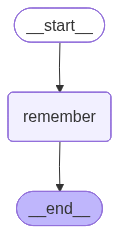

In [6]:
graph = StateGraph(MessagesState)

graph.add_node("remember", remember_node)


graph.add_edge(START, "remember")
graph.add_edge("remember", END)


workflow = graph.compile(store=store)
workflow

In [7]:
config ={"configurable": {"user_id": "user1"}}

workflow.invoke({"messages": [HumanMessage(content = "Hi my name is John")]}, config)


Users Namespace ('user', 'user1', 'details')
Decision does_memory_exist=True memories=["The user's name is John."]


{'messages': [HumanMessage(content='Hi my name is John', additional_kwargs={}, response_metadata={}, id='c66dd631-71c7-4ecd-9131-143c4e142451'),
  AIMessage(content='Noted', additional_kwargs={}, response_metadata={}, id='27551176-f564-4423-a350-6e7676b42fe8', tool_calls=[], invalid_tool_calls=[])]}

In [8]:
config ={"configurable": {"user_id": "user1"}}

workflow.invoke({"messages": [HumanMessage(content = "I like python, can you explain what python is?")]}, config)


Users Namespace ('user', 'user1', 'details')
Decision does_memory_exist=True memories=['I like python']


{'messages': [HumanMessage(content='I like python, can you explain what python is?', additional_kwargs={}, response_metadata={}, id='0452135a-3b02-4634-9f1c-5aece6a9a074'),
  AIMessage(content='Noted', additional_kwargs={}, response_metadata={}, id='cb984293-04b3-462d-a06d-eba682014c2a', tool_calls=[], invalid_tool_calls=[])]}

In [9]:
config ={"configurable": {"user_id": "user1"}}

workflow.invoke({"messages": [HumanMessage(content = "Can you give me the code in python? This is the coding language that I would usually prefer as I understand it better")]}, config)


Users Namespace ('user', 'user1', 'details')
Decision does_memory_exist=True memories=['User prefers Python as their coding language']


{'messages': [HumanMessage(content='Can you give me the code in python? This is the coding language that I would usually prefer as I understand it better', additional_kwargs={}, response_metadata={}, id='7f7e47ba-6ecb-4c6a-8303-39a529a4c238'),
  AIMessage(content='Noted', additional_kwargs={}, response_metadata={}, id='e23cd626-42e0-4f83-a9ee-a320d08ff305', tool_calls=[], invalid_tool_calls=[])]}

- User specific information is getting stored in the memory

# Listing all the memories

In [11]:

items = store.search(('user', 'user1', 'details'))
items

[Item(namespace=['user', 'user1', 'details'], key='dece8167-fa23-4604-be08-bd9d898b6a74', value={'data': "The user's name is John."}, created_at='2026-03-15T07:25:09.187609+00:00', updated_at='2026-03-15T07:25:09.187615+00:00', score=None),
 Item(namespace=['user', 'user1', 'details'], key='8b3146d6-f10e-4452-b4df-2388c753162f', value={'data': 'I like python'}, created_at='2026-03-15T07:25:09.720546+00:00', updated_at='2026-03-15T07:25:09.720549+00:00', score=None),
 Item(namespace=['user', 'user1', 'details'], key='42d3744e-3670-4cf6-b3ee-53f5b566ff8f', value={'data': 'User prefers Python as their coding language'}, created_at='2026-03-15T07:25:10.185510+00:00', updated_at='2026-03-15T07:25:10.185514+00:00', score=None)]

- The flaw with this method is we will be appending duplicate memories too
- For eg: if I user the previous scripts again, those will also be appended, we need to avoid this deduplication
- To avoid this, we can ask LLM to also return if each of the messages already exists in the memory or its a new one
- Finally we can append only those which are newly created